# 가설 3: 해당 지역의 음식점 매출이 높을수록 카페 매출도 같이 높을 것이다

- 분석 기간: 2023년 3분기 ~ 2024년 2분기
- 음식점 업종 코드: CS100001 ~ CS100009
- 카페 업종 코드: CS100010
- 데이터 출처: 서울시 열린 데이터 광장 (http://data.seoul.go.kr/)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. 음식점 월 매출 데이터 가공

In [4]:
# 자치구마다 음식점 월 매출 분석
df=pd.read_csv("../data/서울시 상권분석서비스(추정매출-자치구).csv",encoding='cp949')
df=df.loc[:,["기준_년분기_코드","자치구_코드","자치구_코드_명","서비스_업종_코드",
             "서비스_업종_코드_명","당월_매출_금액"]]

# 2023년 3분기
df_20233=df[df.기준_년분기_코드==20233]
df_20233_list=df_20233.values

# 월 매출
dict_20233_sales_total={}
for list in df_20233_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[5]
    if 100001<=food_code and food_code<=100009:
        dict_20233_sales_total[key]=dict_20233_sales_total.get(key,0)+value
# print(dict_20233_sales_total)

# 2023년 4분기
df_20234=df[df.기준_년분기_코드==20234]
df_20234_list=df_20234.values

# 월 매출
dict_20234_sales_total={}
for list in df_20234_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[5]
    if 100001<=food_code and food_code<=100009:
        dict_20234_sales_total[key]=dict_20234_sales_total.get(key,0)+value
# print(dict_20234_sales_total)

# 2024년 1분기
df_20241=df[df.기준_년분기_코드==20241]
df_20241_list=df_20241.values

# 월 매출
dict_20241_sales_total={}
for list in df_20241_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[5]
    if 100001<=food_code and food_code<=100009:
        dict_20241_sales_total[key]=dict_20241_sales_total.get(key,0)+value
# print(dict_20241_sales_total)

# 2024년 2분기
df_20242=df[df.기준_년분기_코드==20242]
df_20242_list=df_20242.values

# 월 매출
dict_20242_sales_total={}
for list in df_20242_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[5]
    if 100001<=food_code and food_code<=100009:
        dict_20242_sales_total[key]=dict_20242_sales_total.get(key,0)+value
# print(dict_20242_sales_total)

## 2. 카페 월 매출 데이터 가공

In [6]:
# 자치구마다 카페 월 매출 분석
df=pd.read_csv("../data/서울시 상권분석서비스(추정매출-자치구).csv",encoding='cp949')
df=df.loc[:,["기준_년분기_코드","자치구_코드","자치구_코드_명","서비스_업종_코드",
             "서비스_업종_코드_명","당월_매출_금액"]]

# 2023년 3분기
df_20233=df[df.기준_년분기_코드==20233]
df_20233_list=df_20233.values

# 카페 월 매출
dict_20233_sales_cafe={}
for list in df_20233_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[5]
    if food_code==100010:
        dict_20233_sales_cafe[key]=dict_20233_sales_cafe.get(key,0)+value
# print(dict_20233_sales_cafe)

# 2023년 4분기
df_20234=df[df.기준_년분기_코드==20234]
df_20234_list=df_20234.values

# 카페 월 매출
dict_20234_sales_cafe={}
for list in df_20234_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[5]
    if food_code==100010:
        dict_20234_sales_cafe[key]=dict_20234_sales_cafe.get(key,0)+value
# print(dict_20234_sales_cafe)

# 2024년 1분기
df_20241=df[df.기준_년분기_코드==20241]
df_20241_list=df_20241.values

# 카페 월 매출
dict_20241_sales_cafe={}
for list in df_20241_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[5]
    if food_code==100010:
        dict_20241_sales_cafe[key]=dict_20241_sales_cafe.get(key,0)+value
# print(dict_20241_sales_cafe)

# 2024년 2분기
df_20242=df[df.기준_년분기_코드==20242]
df_20242_list=df_20242.values

# 카페 월 매출
dict_20242_sales_cafe={}
for list in df_20242_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[5]
    if food_code==100010:
        dict_20242_sales_cafe[key]=dict_20242_sales_cafe.get(key,0)+value
# print(dict_20242_sales_cafe)

## 3. 산점도 시각화 및 결과

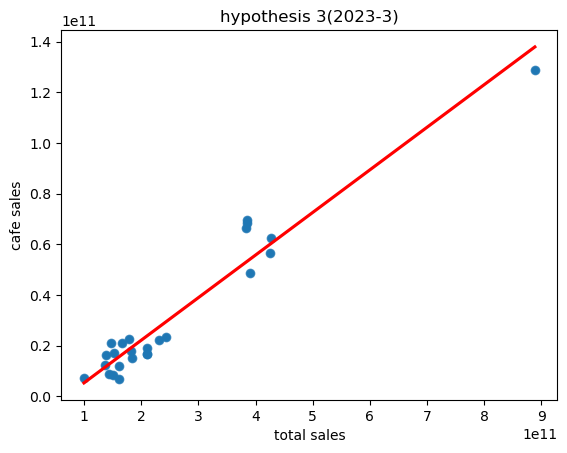

In [8]:
# 2023년 3분기
# [음식점 매출, 카페 매출] 데이터 리스트
data_20233_3=[]
for key in dict_20233_sales_total:
    tempList=[]
    tempList.append(dict_20233_sales_total[key])
    tempList.append(dict_20233_sales_cafe[key])
    data_20233_3.append(tempList)
# print(data_20233_3)

# 그래프
df_20233=pd.DataFrame(data_20233_3,columns=["total sales","cafe sales"])
graph=df_20233.plot.scatter(x="total sales",y="cafe sales",title="hypothesis 3(2023-3)")
graph=sns.regplot(x="total sales",y="cafe sales",ci=None,data=df_20233,line_kws={"color":"red"})

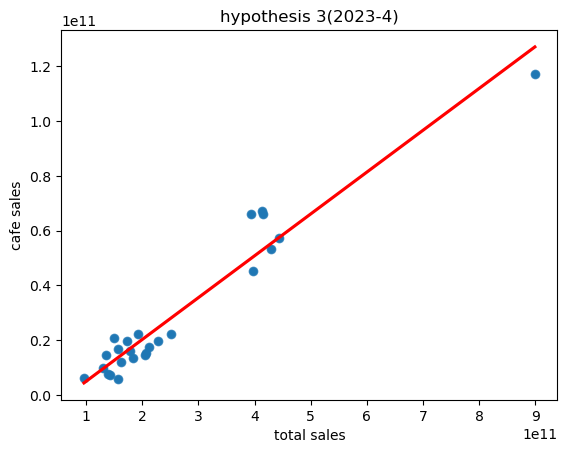

In [9]:
# 2023년 4분기
# [음식점 매출, 카페 매출] 데이터 리스트
data_20234_3=[]
for key in dict_20234_sales_total:
    tempList=[]
    tempList.append(dict_20234_sales_total[key])
    tempList.append(dict_20234_sales_cafe[key])
    data_20234_3.append(tempList)
# print(data_20234_3)

# 그래프
df_20234=pd.DataFrame(data_20234_3,columns=["total sales","cafe sales"])
graph=df_20234.plot.scatter(x="total sales",y="cafe sales",title="hypothesis 3(2023-4)")
graph=sns.regplot(x="total sales",y="cafe sales",ci=None,data=df_20234,line_kws={"color":"red"})

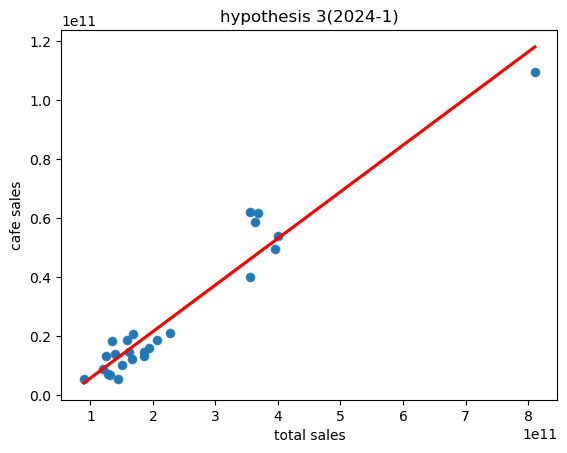

In [10]:
# 2024년 1분기
# [음식점 매출, 카페 매출] 데이터 리스트
data_20241_3=[]
for key in dict_20241_sales_total:
    tempList=[]
    tempList.append(dict_20241_sales_total[key])
    tempList.append(dict_20241_sales_cafe[key])
    data_20241_3.append(tempList)
# print(data_20241_3)

# 그래프
df_20241=pd.DataFrame(data_20241_3,columns=["total sales","cafe sales"])
graph=df_20241.plot.scatter(x="total sales",y="cafe sales",title="hypothesis 3(2024-1)")
graph=sns.regplot(x="total sales",y="cafe sales",ci=None,data=df_20241,line_kws={"color":"red"})

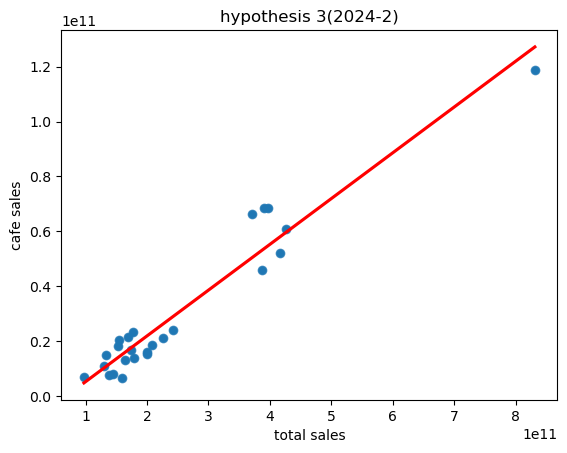

In [11]:
# 2024년 2분기
# [음식점 매출, 카페 매출] 데이터 리스트
data_20242_3=[]
for key in dict_20242_sales_total:
    tempList=[]
    tempList.append(dict_20242_sales_total[key])
    tempList.append(dict_20242_sales_cafe[key])
    data_20242_3.append(tempList)
# print(data_20242_3)

# 그래프
df_20242=pd.DataFrame(data_20242_3,columns=["total sales","cafe sales"])
graph=df_20242.plot.scatter(x="total sales",y="cafe sales",title="hypothesis 3(2024-2)")
graph=sns.regplot(x="total sales",y="cafe sales",ci=None,data=df_20242,line_kws={"color":"red"})

## 4. 결론

가설 2보다도 그래프에 그려진 추세선의 기울기가 양수이고, 추세선에 데이터가 꽤 근접해 있기 때문에  
**서울 지역별 음식점 매출과 카페 매출은 정비례한다**고 볼 수 있다.

밥을 먹고 카페에 가서 커피나 음료수를 먹는 문화가 있다보니  
음식점의 매출이 높은 지역일수록 카페의 매출도 높은 것으로 확인되었다.